In [ ]:
import pandas as pd
import numpy as np

# ==============================
# Load raw KDDTest+
# ==============================

test_columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"
]

test_raw = pd.read_csv(
    "../data/KDDTest+.txt",
    header=None
)

test_raw.columns = test_columns

# همان 17 حمله‌ای که در Train وجود نداشتند
train_raw = pd.read_csv(
    "../data/KDDTrain+.txt",
    header=None
)
train_raw.columns = test_columns

train_attacks = set(
    train_raw.loc[
        train_raw["label"] != "normal",
        "label"
    ].unique()
)

test_attacks = set(
    test_raw.loc[
        test_raw["label"] != "normal",
        "label"
    ].unique()
)

unseen_attacks = sorted(test_attacks - train_attacks)

print("Unseen attacks:")
print(unseen_attacks)

In [ ]:
zero_day_mask = test_raw["label"].isin(unseen_attacks)

zero_day_labels = test_raw.loc[
    zero_day_mask,
    "label"
].reset_index(drop=True)

print("Zero-Day samples:", len(zero_day_labels))
print("\nDistribution:")
print(zero_day_labels.value_counts().sort_index())

In [ ]:
import joblib

X_test_zero_day = joblib.load("../data/X_test_zero_day.pkl")
y_test_zero_day = joblib.load("../data/y_test_zero_day.pkl")

print("X_test_zero_day shape :", X_test_zero_day.shape)
print("y_test_zero_day shape :", y_test_zero_day.shape)

In [ ]:
assert len(zero_day_labels) == len(X_test_zero_day)

print("X_test_zero_day shape :", X_test_zero_day.shape)
print("zero_day_labels shape :", zero_day_labels.shape)

print("\n✅ Alignment check passed!")

In [ ]:
# ==========================================
# Load Zero-Day datasets
# ==========================================

import joblib

X_train = joblib.load("../data/X_train_zero_day.pkl")
y_train = joblib.load("../data/y_train_zero_day.pkl")

X_test_seen = joblib.load("../data/X_test_seen.pkl")
y_test_seen = joblib.load("../data/y_test_seen.pkl")

X_test_zero_day = joblib.load("../data/X_test_zero_day.pkl")
y_test_zero_day = joblib.load("../data/y_test_zero_day.pkl")

# Scaled versions
X_train_scaled = joblib.load("../data/X_train_zero_day_scaled.pkl")
X_test_seen_scaled = joblib.load("../data/X_test_seen_scaled.pkl")
X_test_zero_day_scaled = joblib.load("../data/X_test_zero_day_scaled.pkl")


print("✅ Datasets loaded successfully!")

print("\nShapes:")
print("X_train              :", X_train.shape)
print("y_train              :", y_train.shape)
print("X_test_seen          :", X_test_seen.shape)
print("y_test_seen          :", y_test_seen.shape)
print("X_test_zero_day      :", X_test_zero_day.shape)
print("y_test_zero_day      :", y_test_zero_day.shape)

print("\nScaled:")
print("X_train_scaled       :", X_train_scaled.shape)
print("X_test_seen_scaled   :", X_test_seen_scaled.shape)
print("X_test_zero_day_scaled:", X_test_zero_day_scaled.shape)

In [6]:
# ==========================================
# Define and train baseline models
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Decision Tree
# -----------------------------
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)


# -----------------------------
# Random Forest
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# -----------------------------
# KNN
# -----------------------------
knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)


# -----------------------------
# Linear SVM
# -----------------------------
svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm.fit(X_train_scaled, y_train)


# -----------------------------
# Logistic Regression
# -----------------------------
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)


print("✅ All models trained successfully!")

✅ All models trained successfully!


In [7]:
# ==============================
# Predictions
# ==============================

predictions = {}

# Decision Tree
predictions["Decision Tree"] = dt.predict(
    X_test_zero_day
)

# Random Forest
predictions["Random Forest"] = rf.predict(
    X_test_zero_day
)

# KNN
predictions["KNN"] = knn.predict(
    X_test_zero_day_scaled
)

# Linear SVM
predictions["Linear SVM"] = svm.predict(
    X_test_zero_day_scaled
)

# Logistic Regression
predictions["Logistic Regression"] = lr.predict(
    X_test_zero_day_scaled
)

print("✅ Predictions completed!")

✅ Predictions completed!


In [8]:
results_per_attack = []

for attack in sorted(unseen_attacks):

    mask = zero_day_labels == attack

    row = {
        "Attack": attack,
        "Samples": mask.sum()
    }

    for model_name, y_pred in predictions.items():

        detection_rate = np.mean(
            y_pred[mask] == 1
        )

        row[model_name] = detection_rate * 100

    results_per_attack.append(row)


per_attack_df = pd.DataFrame(results_per_attack)

per_attack_df

,Attack,Samples,Decision Tree,Random Forest,KNN,Linear SVM,Logistic Regression
0,apache2,737,45.318860,18.724559,70.827680,99.050204,99.050204
1,httptunnel,133,12.030075,4.511278,12.030075,1.503759,1.503759
2,mailbomb,293,0.000000,0.000000,0.000000,0.000000,0.000000
3,mscan,996,53.112450,34.236948,76.907631,32.630522,47.791165
4,named,17,35.294118,11.764706,23.529412,5.882353,5.882353
5,processtable,685,31.532847,2.481752,0.583942,0.437956,0.291971
6,ps,15,60.000000,13.333333,13.333333,0.000000,0.000000
7,saint,319,99.059561,98.432602,95.924765,95.297806,95.611285
8,sendmail,14,0.000000,0.000000,28.571429,7.142857,7.142857
9,snmpgetattack,178,0.000000,0.000000,0.000000,0.000000,0.561798


In [9]:
normal_mask = y_test_seen == 0

normal_predictions = {}

normal_predictions["Decision Tree"] = dt.predict(
    X_test_seen
)

normal_predictions["Random Forest"] = rf.predict(
    X_test_seen
)

normal_predictions["KNN"] = knn.predict(
    X_test_seen_scaled
)

normal_predictions["Linear SVM"] = svm.predict(
    X_test_seen_scaled
)

normal_predictions["Logistic Regression"] = lr.predict(
    X_test_seen_scaled
)

In [10]:
fpr_results = []

for model_name, y_pred in normal_predictions.items():

    false_positives = np.sum(
        y_pred[normal_mask] == 1
    )

    total_normal = np.sum(normal_mask)

    fpr = false_positives / total_normal

    fpr_results.append({
        "Model": model_name,
        "False Positives": false_positives,
        "Total Normal": total_normal,
        "False Positive Rate (%)": fpr * 100
    })


fpr_df = pd.DataFrame(fpr_results)

fpr_df

,Model,False Positives,Total Normal,False Positive Rate (%)
0,Decision Tree,304,9711,3.130471
1,Random Forest,266,9711,2.739162
2,KNN,693,9711,7.136237
3,Linear SVM,726,9711,7.476058
4,Logistic Regression,721,9711,7.424570


In [11]:
# ============================================
# Baseline Trade-off: Zero-Day Detection vs FPR
# ============================================

zero_day_summary = pd.DataFrame([
    {
        "Model": model_name,
        "Zero-Day Detection Rate (%)": np.mean(y_pred_zero_day == 1) * 100
    }
    for model_name, y_pred_zero_day in predictions.items()
])

baseline_tradeoff = zero_day_summary.merge(
    fpr_df,
    on="Model"
)

baseline_tradeoff

,Model,Zero-Day Detection Rate (%),False Positives,Total Normal,False Positive Rate (%)
0,Decision Tree,38.266667,304,9711,3.130471
1,Random Forest,22.026667,266,9711,2.739162
2,KNN,43.520000,693,9711,7.136237
3,Linear SVM,36.533333,726,9711,7.476058
4,Logistic Regression,40.640000,721,9711,7.424570


In [ ]:
# ============================================
# Baseline Trade-off Data
# ============================================

zero_day_summary = pd.DataFrame([
    {
        "Model": model_name,
        "Zero-Day Detection Rate (%)": np.mean(y_pred_zero_day == 1) * 100
    }
    for model_name, y_pred_zero_day in predictions.items()
])

baseline_tradeoff = zero_day_summary.merge(
    fpr_df,
    on="Model"
)

print(baseline_tradeoff)


                 Model  Zero-Day Detection Rate (%)  False Positives  \
0        Decision Tree                    38.266667              304   
1        Random Forest                    22.026667              266   
2                  KNN                    43.520000              693   
3           Linear SVM                    36.533333              726   
4  Logistic Regression                    40.640000              721   

   Total Normal  False Positive Rate (%)  
0          9711                 3.130471  
1          9711                 2.739162  
2          9711                 7.136237  
3          9711                 7.476058  
4          9711                 7.424570  


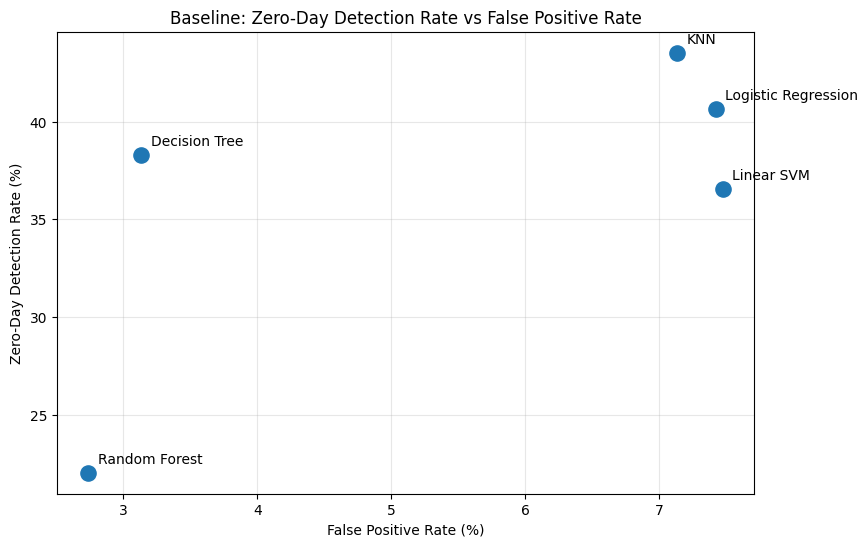

In [15]:
# ============================================
# Zero-Day Detection Rate vs FPR
# ============================================
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))

plt.scatter(
    baseline_tradeoff["False Positive Rate (%)"],
    baseline_tradeoff["Zero-Day Detection Rate (%)"],
    s=120
)

for _, row in baseline_tradeoff.iterrows():
    plt.annotate(
        row["Model"],
        (
            row["False Positive Rate (%)"],
            row["Zero-Day Detection Rate (%)"]
        ),
        xytext=(7, 7),
        textcoords="offset points"
    )

plt.xlabel("False Positive Rate (%)")
plt.ylabel("Zero-Day Detection Rate (%)")
plt.title("Baseline: Zero-Day Detection Rate vs False Positive Rate")

plt.grid(alpha=0.3)
plt.show()